In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output

In [10]:
# import the necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import pandas as pd
data = pd.read_csv("creditcard.csv")

In [12]:
# Start exploring the dataset
print(data.columns)
data.head()

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
# Print the shape of the data
# data = data.sample(frac=0.1, random_state = 48)
print(data.shape)
print(data.describe())

# V1 - V28 are the results of a PCA Dimensionality reduction to protect user identities and sensitive features

(284807, 31)
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271

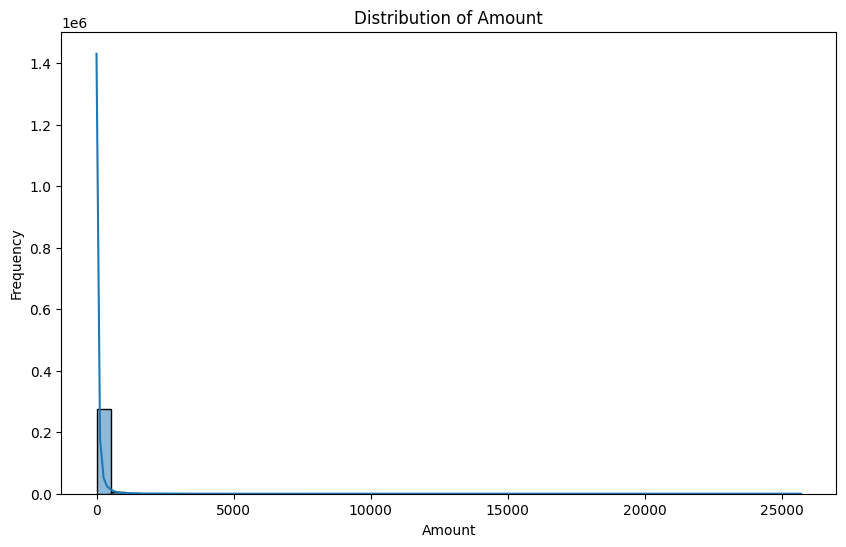

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the histogram with KDE overlay
plt.figure(figsize=(10, 6))
sns.histplot(data['Amount'], bins=50, kde=True)

# Adding labels
plt.title('Distribution of Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()



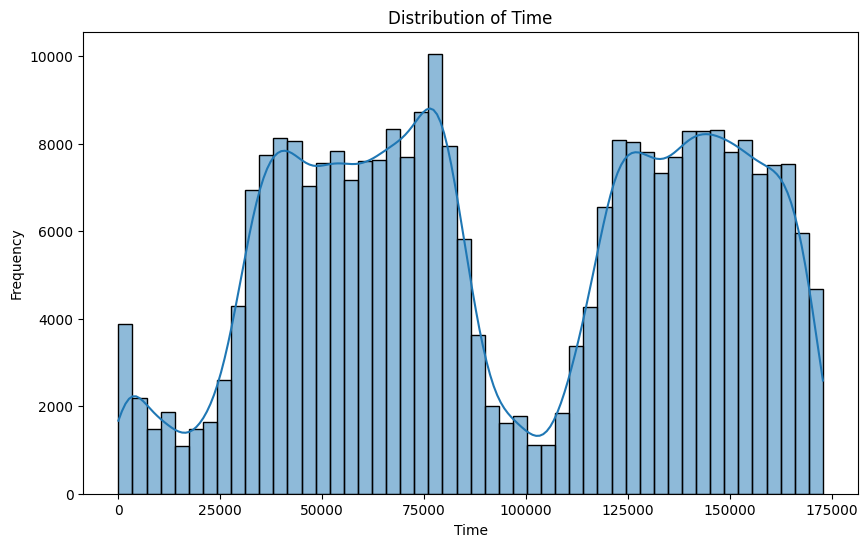

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the histogram with KDE overlay
plt.figure(figsize=(10, 6))
sns.histplot(data['Time'], bins=50, kde=True)

# Adding labels
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()



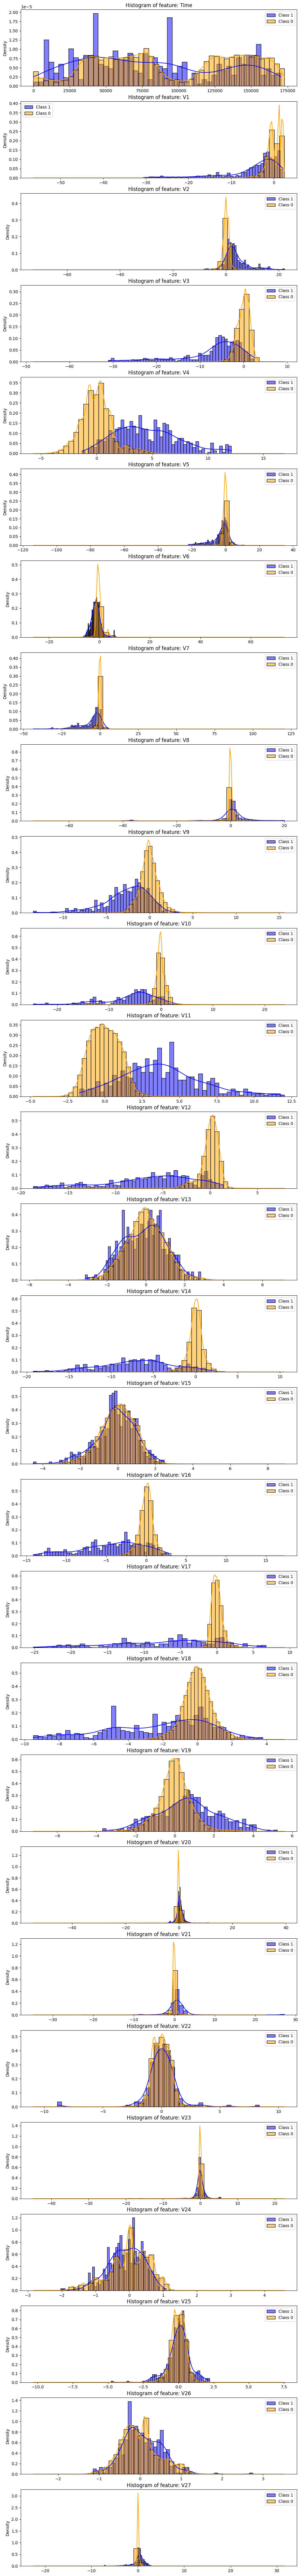

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

# Assuming 'data' is already defined and contains your dataset
features = data.iloc[:, 0:28].columns

plt.figure(figsize=(12, 28 * 4))
gs = gridspec.GridSpec(28, 1)

for i, c in enumerate(data[features]):
    ax = plt.subplot(gs[i])
    # Use histplot instead of distplot
    sns.histplot(data[c][data.Class == 1], bins=50, kde=True, ax=ax, color='blue', label='Class 1', stat='density')
    sns.histplot(data[c][data.Class == 0], bins=50, kde=True, ax=ax, color='orange', label='Class 0', stat='density')
    ax.set_xlabel('')
    ax.set_title('Histogram of feature: ' + str(c))
    ax.legend()

plt.show()

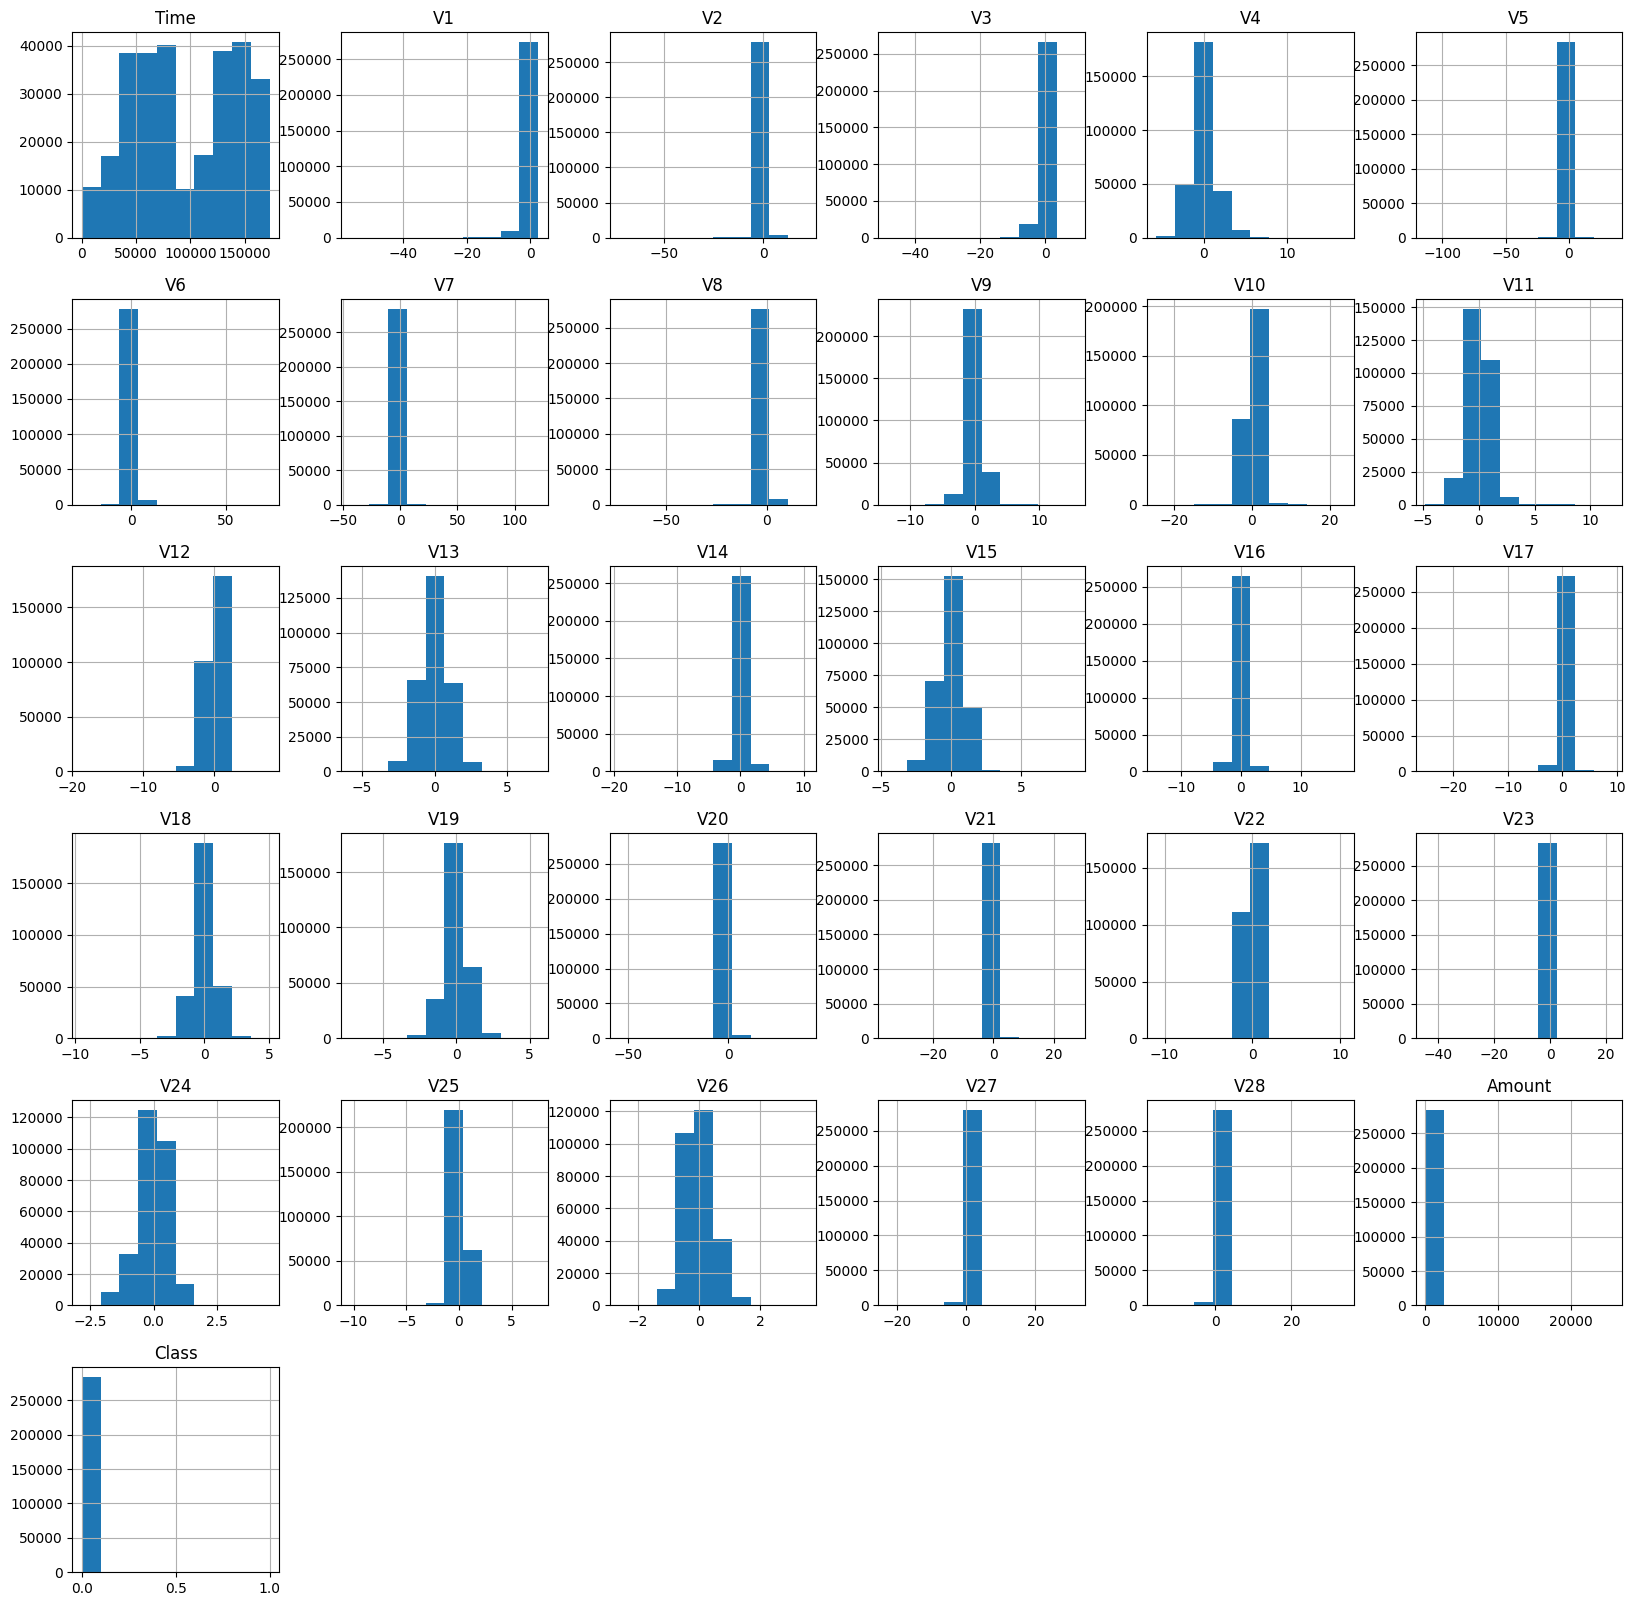

In [17]:
# Plot histograms of each parameter 
data.hist(figsize = (20, 20))
plt.show()

In [18]:
# Determine number of fraud cases in dataset

Fraud = data[data['Class'] == 1]
Valid = data[data['Class'] == 0]

outlier_fraction = len(Fraud)/float(len(Valid))
print(outlier_fraction)

print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315


In [19]:
print("Amount details of fradulent transacation")
Fraud.Amount.describe()

Amount details of fradulent transacation


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [20]:
print("Amount details of valid transaction")
Valid.Amount.describe()

Amount details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

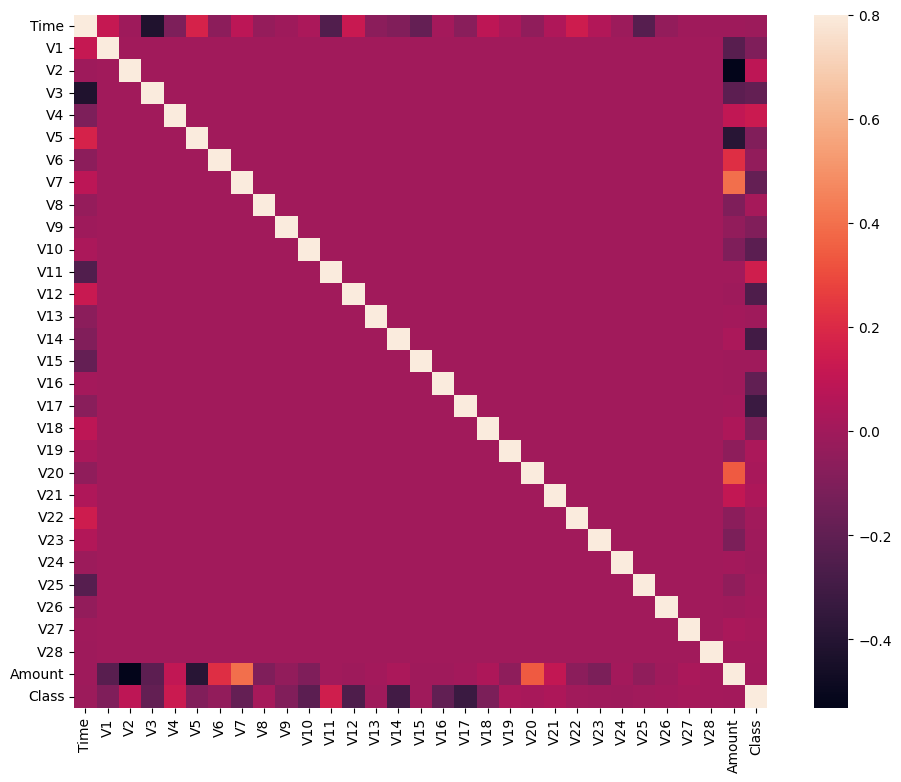

In [21]:
# Correlation matrix
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))

sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [22]:
#seperating the X and the Y from the dataset
X=data.drop(['Class'], axis=1)
Y=data["Class"]
print(X.shape)
print(Y.shape)
#getting just the values for the sake of processing (its a numpy array with no columns)
X_data=X.values
Y_data=Y.values

(284807, 30)
(284807,)


In [23]:
X_data

array([[ 0.00000000e+00, -1.35980713e+00, -7.27811733e-02, ...,
         1.33558377e-01, -2.10530535e-02,  1.49620000e+02],
       [ 0.00000000e+00,  1.19185711e+00,  2.66150712e-01, ...,
        -8.98309914e-03,  1.47241692e-02,  2.69000000e+00],
       [ 1.00000000e+00, -1.35835406e+00, -1.34016307e+00, ...,
        -5.53527940e-02, -5.97518406e-02,  3.78660000e+02],
       ...,
       [ 1.72788000e+05,  1.91956501e+00, -3.01253846e-01, ...,
         4.45477214e-03, -2.65608286e-02,  6.78800000e+01],
       [ 1.72788000e+05, -2.40440050e-01,  5.30482513e-01, ...,
         1.08820735e-01,  1.04532821e-01,  1.00000000e+01],
       [ 1.72792000e+05, -5.33412522e-01, -1.89733337e-01, ...,
        -2.41530880e-03,  1.36489143e-02,  2.17000000e+02]])

In [24]:
# Using Skicit-learn to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, test_size = 0.2, random_state = 42)

In [25]:
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import confusion_matrix

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load your dataset (ensure the path is correct)
file_path = r'C:\Local disk (D)\Project Pinnacle\cc_fraud\creditcard.csv'
data = pd.read_csv(file_path)

# Verify the existence of the 'Class' column in the dataset
if 'Class' not in data.columns:
    raise ValueError("The 'Class' column is missing from the dataset.")

# Define features and the target variable
features = data.drop(columns=['Class'])  # Features: all columns except 'Class'
target = data['Class']                    # Target variable: 'Class'

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create and train the Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)  # Fit the model using training data

# Make predictions on the test set
y_predictions = random_forest_model.predict(X_test)

# Display predictions (optional)
print("Predictions on the test set:", y_predictions)

# Evaluate the model's performance
# Calculate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_predictions)
print("Accuracy:", accuracy)

# Generate and print classification report
class_report = classification_report(y_test, y_predictions)
print("Classification Report:")
print(class_report)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (ensure the path is correct)
file_path = r'C:\Local disk (D)\Project Pinnacle\cc_fraud\creditcard.csv'
data = pd.read_csv(file_path)

# Verify the existence of the 'Class' column in the dataset
if 'Class' not in data.columns:
    raise ValueError("The 'Class' column is missing from the dataset.")

# Define features and the target variable
X = data.drop(columns=['Class'])  # Features: all columns except 'Class'
y = data['Class']                  # Target variable: 'Class'

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X_train, y_train)  # Fit the model using training data

# Make predictions on the test set
y_pred = random_forest_model.predict(X_test)

# Calculating metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
n_errors = (y_pred != y_test).sum()  # Total errors

# Displaying results
print("The model used is Random Forest classifier")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1-Score: {f1 * 100:.2f}%")

# Explanation of each metric
print("\nExplanation of Metrics:")
print("Accuracy: The proportion of true results (both true positives and true negatives) among the total number of cases examined.")
print("Precision: The ratio of correctly predicted positive observations to the total predicted positives. It indicates the quality of the positive class predictions.")
print("Recall: The ratio of correctly predicted positive observations to all actual positives. It indicates how well the model identifies positive cases.")
print("F1-Score: The harmonic mean of precision and recall, providing a balance between the two. It is useful for imbalanced classes.")

# Printing the confusion matrix
LABELS = ['Normal', 'Fraud']
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 12))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d", cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

# Run classification metrics
plt.figure(figsize=(9, 7))
print('{}: {}'.format("Random Forest", n_errors))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


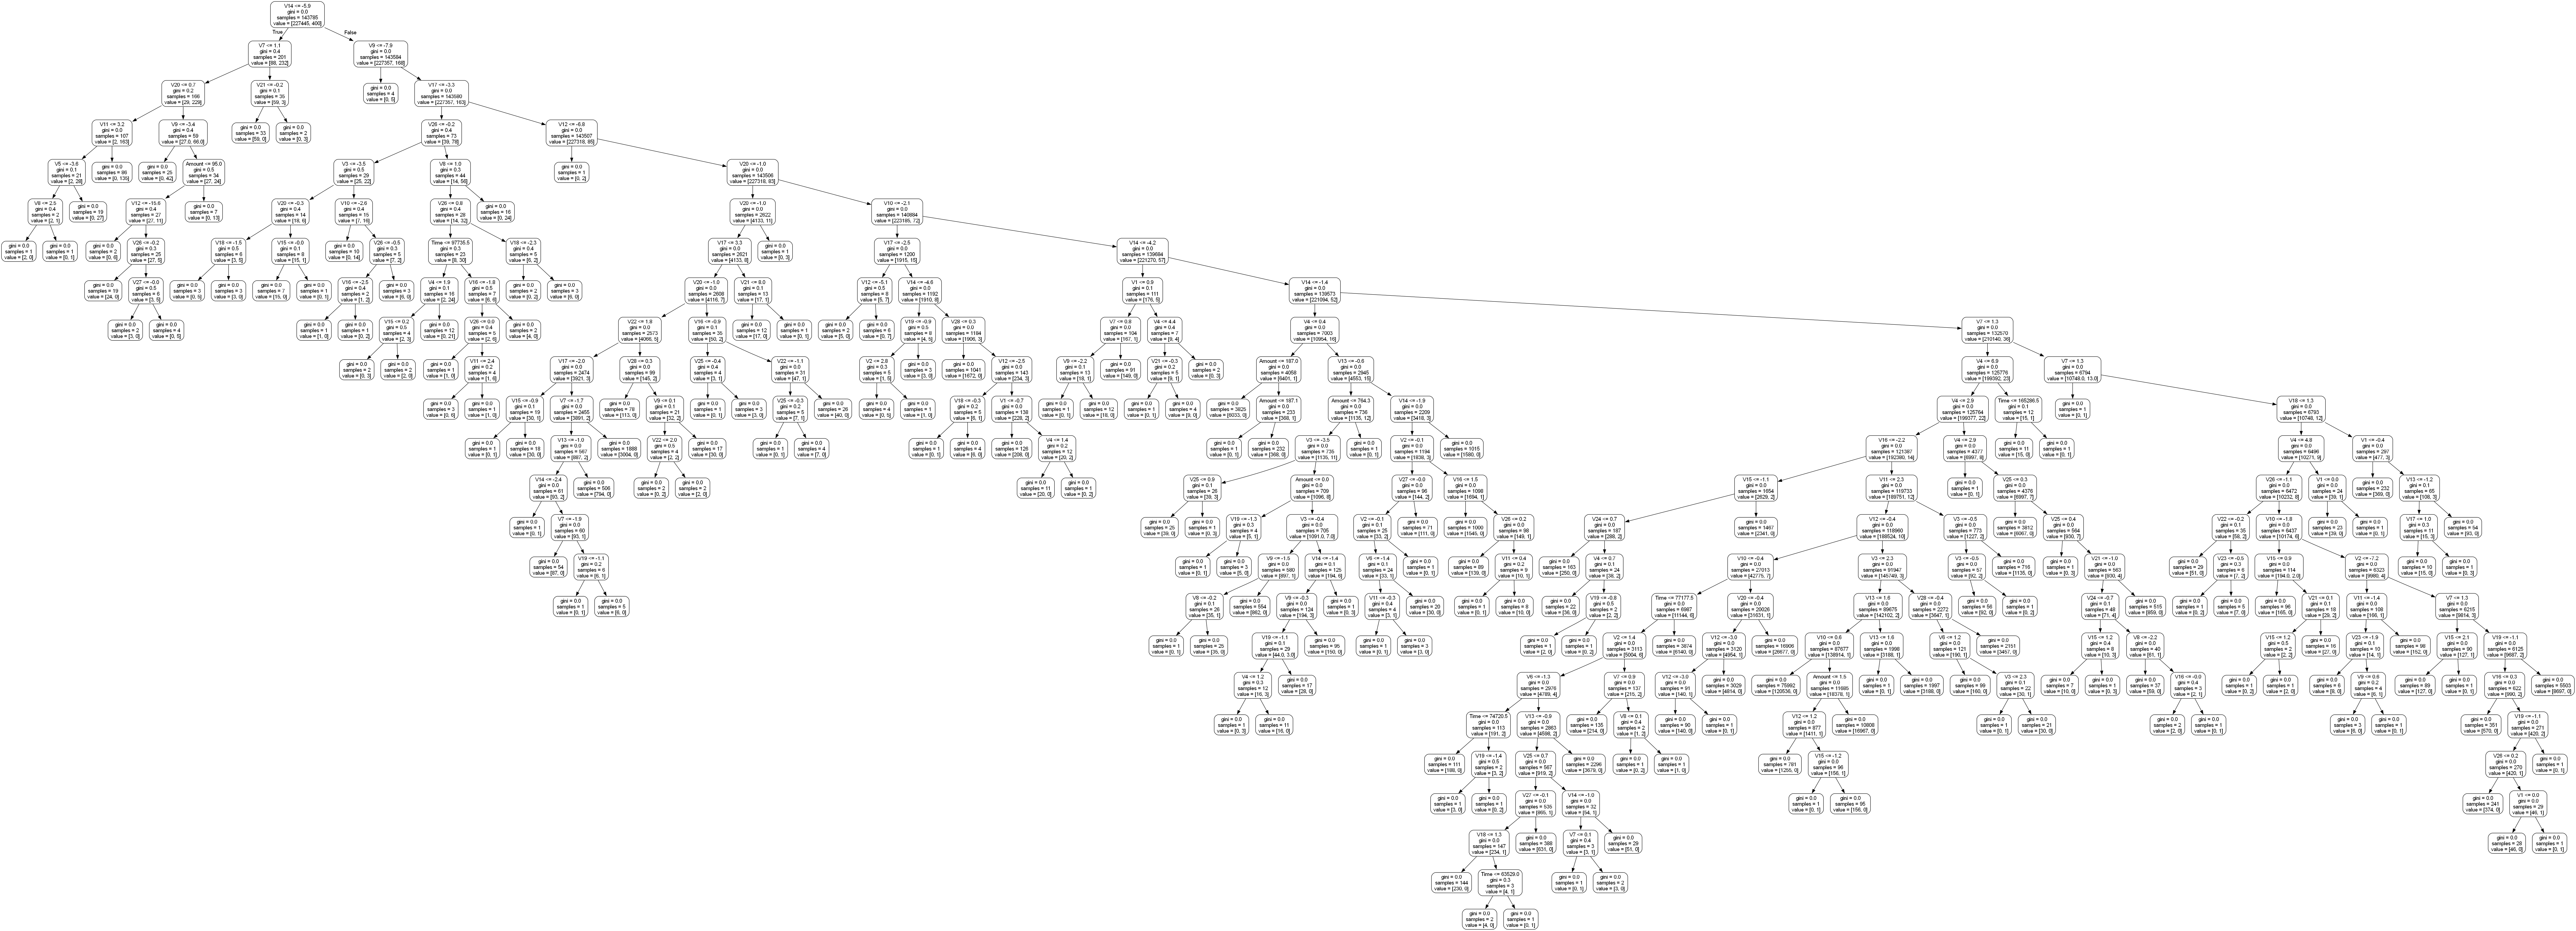

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
import pydot
from IPython.display import Image, display

# Load your dataset (ensure the path is correct)
file_path = r'C:\Local disk (D)\Project Pinnacle\cc_fraud\creditcard.csv'
data = pd.read_csv(file_path)

# Verify the existence of the 'Class' column in the dataset
if 'Class' not in data.columns:
    raise ValueError("The 'Class' column is missing from the dataset.")

# Define features and the target variable
X = data.drop(columns=['Class'])  # Features: all columns except 'Class'
y = data['Class']                  # Target variable: 'Class'

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create and train the Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)  # Fit the model using training data

# Visualizing a random tree from the forest
feature_list = list(X.columns)
tree = random_forest_model.estimators_[5]  # Pulling out one tree from the forest
export_graphviz(tree, out_file='tree.dot', feature_names=feature_list, rounded=True, precision=1)

# Use dot file to create a graph
(graph,) = pydot.graph_from_dot_file('tree.dot')

# Write graph to a PNG file
graph.write_png('random_forest_tree.png')

# Display the PNG image
display(Image('random_forest_tree.png'))


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib  # Library for saving/loading models

# Load your dataset (ensure the path is correct)
file_path = r'C:\Local disk (D)\Project Pinnacle\cc_fraud\creditcard.csv'
data = pd.read_csv(file_path)

# Verify the existence of the 'Class' column in the dataset
if 'Class' not in data.columns:
    raise ValueError("The 'Class' column is missing from the dataset.")

# Define features and the target variable
X = data.drop(columns=['Class'])  # Features: all columns except 'Class'
y = data['Class']                  # Target variable: 'Class'

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create and train the Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=225, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)  # Fit the model using training data

# Save the model
joblib.dump(random_forest_model, 'random_forest_model.pkl')  # Save the model to a file

print("Model saved as 'random_forest_model.pkl'")


Model saved as 'random_forest_model.pkl'


In [1]:
import pickle

try:
    # Load the model
    with open('C:\\Local disk (D)\\Project Pinnacle\\cc_fraud\\random_forest_model.pkl', 'rb') as file:
        model = pickle.load(file)
    print("Model loaded successfully!")
except FileNotFoundError:
    print("The specified file was not found.")
except pickle.UnpicklingError:
    print("Error unpickling the file. It may be corrupted or not a valid pickle file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Model loaded successfully!
